In [17]:
import pickle

# load the data
#with open('best_model_dict_20260125_v1.pkl', 'rb') as f:
#    best_model = pickle.load(f)

x = best_model[9]
y = best_model[10]

C:\Users\phyrma\AppData\Local\Temp\ipykernel_132572\3396515878.py:36: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  if len(cs.collections) > 0:
C:\Users\phyrma\AppData\Local\Temp\ipykernel_132572\3396515878.py:37: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  cs.collections[0].remove()  # remove the outermost contour


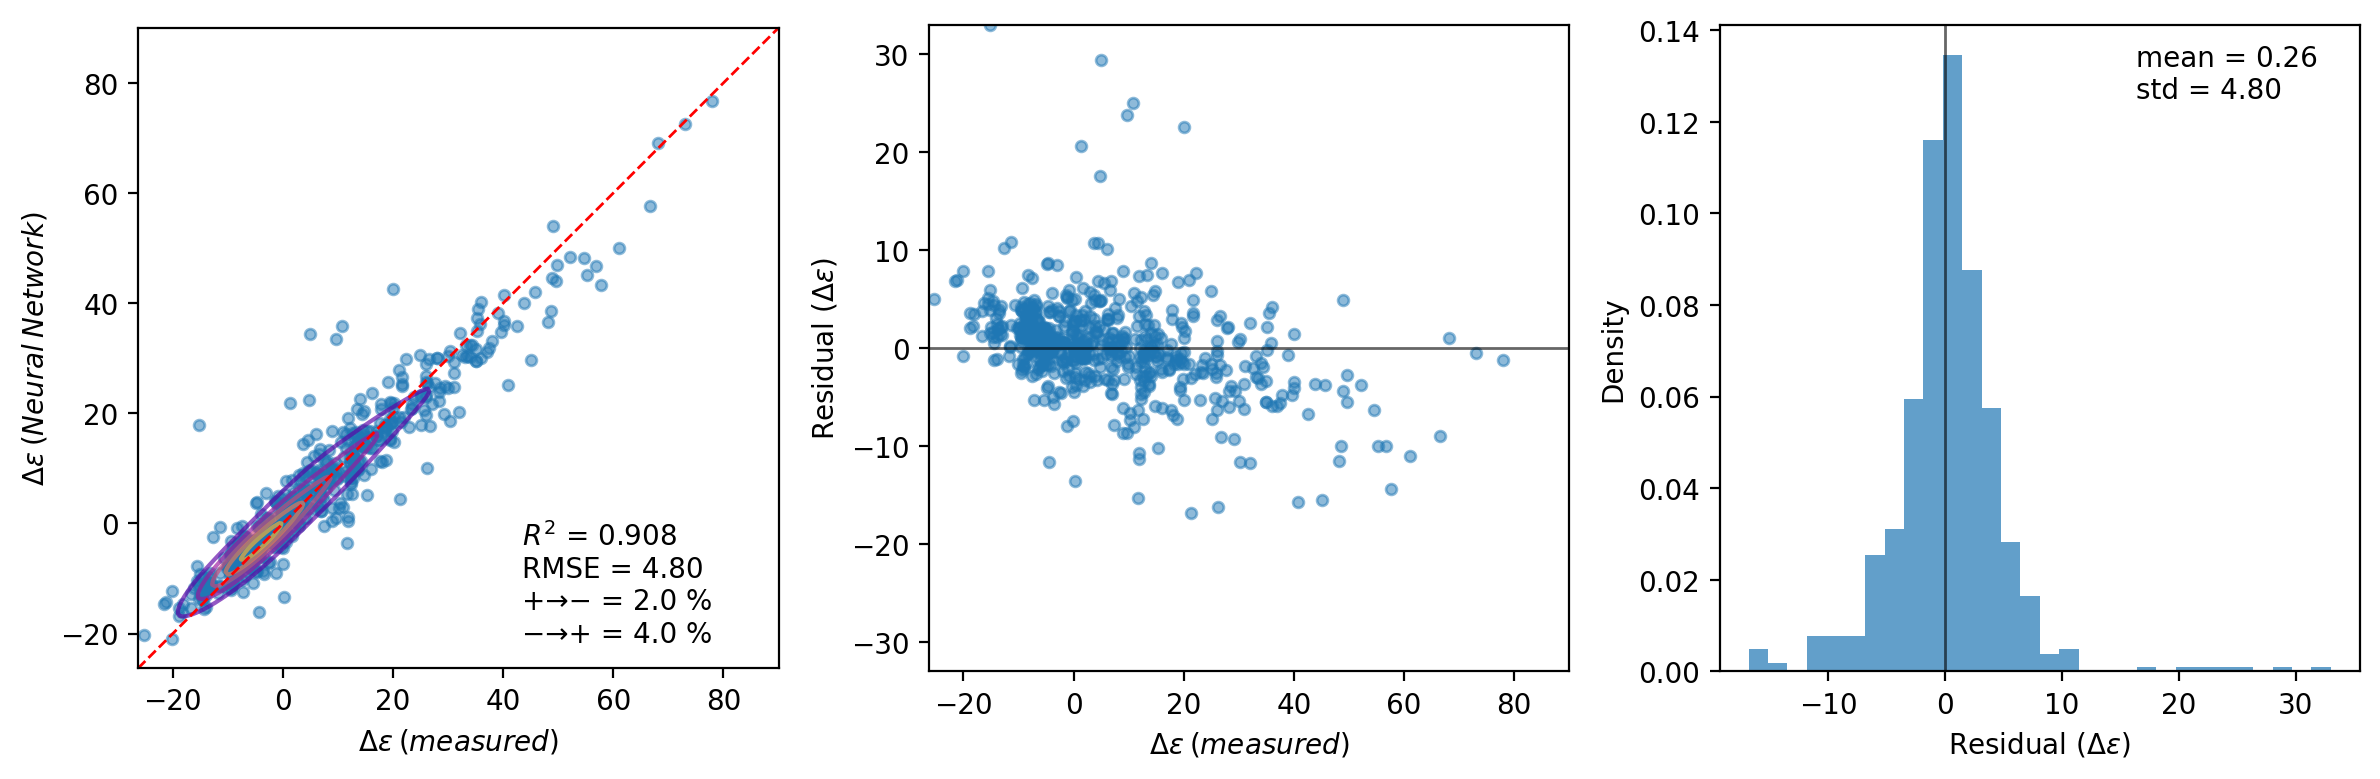

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import gaussian_kde


def add_panel_label(ax, label):
    ax.text(
        0.02, 0.02, label,
        transform=ax.transAxes,
        ha="left", va="bottom",
        fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, linewidth=0)
    )


def density_panel(ax, x, y, xlabel, ylabel, minima, maxima=100, ngrid=200,
                  n_contours=6, scatter_n=5000, panel_label="(a)"):
    """
    plot predict vs actuals with KDE contours (becase the data is so dense) + light scatter.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    rmse = np.sqrt(mean_squared_error(x, y))
    r2   = r2_score(x, y)

    xi = np.linspace(minima, maxima, ngrid)
    yi = np.linspace(minima, maxima, ngrid)
    Xg, Yg = np.meshgrid(xi, yi)

    kde = gaussian_kde(np.vstack([x, y]))
    Zg = kde(np.vstack([Xg.ravel(), Yg.ravel()])).reshape(Xg.shape)

    cs = ax.contour(Xg, Yg, Zg, levels=n_contours, cmap='plasma', alpha=0.66)
    if len(cs.collections) > 0:
        cs.collections[0].remove()  # remove the outermost contour because it looks ugly (way off the data)

    # light scatter overlay
    if len(x) > scatter_n:
        idx = np.random.choice(len(x), size=scatter_n, replace=False)
        xs, ys = x[idx], y[idx]
    else:
        xs, ys = x, y

    ax.scatter(xs, ys, s=15, alpha=0.5)
    ax.plot([minima, maxima], [minima, maxima], 'r--', linewidth=1)

    ax.set_xlim(minima, maxima)
    ax.set_ylim(minima, maxima)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.text(
        0.6, 0.23,
        f"$R^2$ = {r2:.3f}\n"
        f"RMSE = {rmse:.2f}\n"
        f"+→− = {p2n} %\n"
        f"−→+ = {n2p} %",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, linewidth=0)
    )

    add_panel_label(ax, panel_label)
    return rmse, r2


def residuals_vs_measured(ax, x, y, minima, maxima, scatter_n=5000, panel_label="(b)"):
    """
    scatter plot of residuals vs measured Δε.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    res = y - x

    # subsample for clarity
    if len(x) > scatter_n:
        idx = np.random.choice(len(x), size=scatter_n, replace=False)
        xs, rs = x[idx], res[idx]
    else:
        xs, rs = x, res

    # Probably most of the time we want to pick the ylims from the data, but actually for comparison in the paper lets just manaully set the limits to match the earlier figure.
    rclean = res[np.isfinite(res)]
    if rclean.size:
        q = np.nanquantile(np.abs(rclean), 0.98)
        lim = 33 # max(5.0, float(np.ceil(q)))
    else:
        lim = 30

    ax.axhline(0, color='k', lw=1, alpha=0.6)
    ax.scatter(xs, rs, s=15, alpha=0.5)

    ax.set_xlim(minima, maxima)
    ax.set_ylim(-lim, lim)

    ax.set_xlabel(r"$\Delta\epsilon\:(measured)$")
    ax.set_ylabel(r"Residual ($\Delta\epsilon$)")
    add_panel_label(ax, panel_label)


def residual_hist(ax, x, y, panel_label="(c)"):
    """
    histogram of residuals.
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    res = (y - x)
    res = res[np.isfinite(res)]

    ax.hist(res, bins=30, density=True, alpha=0.7)
    ax.axvline(0, color='k', lw=1, alpha=0.6)

    mu = np.nanmean(res) if res.size else np.nan
    sig = np.nanstd(res) if res.size else np.nan

    ax.text(
        0.65, 0.97,
        f"mean = {mu:.2f}\nstd = {sig:.2f}",
        transform=ax.transAxes,
        va="top", ha="left",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, linewidth=0)
    )

    ax.set_xlabel(r"Residual ($\Delta\epsilon$)")
    ax.set_ylabel("Density")
    add_panel_label(ax, panel_label)


def sign_error_breakdown(x, y, drop_zero=True):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if drop_zero:
        m = (x != 0) & (y != 0)
        x, y = x[m], y[m]
    pos_to_neg = np.round((np.sum((x > 0) & (y < 0)) / len(x))*100,0)
    neg_to_pos = np.round((np.sum((x < 0) & (y > 0)) / len(x))*100,0)
    return pos_to_neg, neg_to_pos, len(x)



x = np.asarray(best_model[9], dtype=float)   # measured
y = np.asarray(best_model[10], dtype=float)  # predicted

minima = np.nanmin([x, y]) - 1
maxima = 90

fig, axes = plt.subplots(1, 3, figsize=(12, 4), dpi=200)
p2n, n2p, n = sign_error_breakdown(x, y)
density_panel(
    axes[0], x, y,
    xlabel=r"$\Delta\epsilon\:(measured)$",
    ylabel=r"$\Delta\epsilon\:(Neural \: Network)$",
    minima=minima, maxima=maxima,
    n_contours=6, scatter_n=5000,
    panel_label=""
)

residuals_vs_measured(
    axes[1], x, y,
    minima=minima, maxima=maxima,
    scatter_n=5000,
    panel_label=""
)

residual_hist(
    axes[2], x, y,
    panel_label=""
)

plt.tight_layout()
plt.show()
